# Feature Engineering

This notebook creates:
- Lag features
- Rolling averages
- Trend indicators
- Seasonal features

In [30]:
# =========================================
# IMPORT PROJECT MODULES
# =========================================

import sys
import importlib

PROJECT_PATH = "/content/drive/MyDrive/Agribora_Final"

# Add project path
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

# Import modules
import data_loader
import preprocessing
import feature


importlib.reload(data_loader)
importlib.reload(preprocessing)
importlib.reload(feature)

print("Modules imported successfully ")

Modules imported successfully 


In [20]:
data = data_loader.load_all_data()

df = data['agri_df']  # main dataset

Loaded: agriBORA_maize_prices.csv
Shape : (239, 6)
Loaded: agriBORA_maize_prices_weeks_46_to_51.csv
Shape : (30, 6)
Loaded: kamis_maize_prices.csv
Shape : (21888, 15)
Loaded: kamis_maize_prices_raw.csv
Shape : (22525, 16)
Loaded: agriBORA_Final_Weeks_maize_price.csv
Shape : (10, 4)

All datasets loaded successfully


In [31]:
TARGET_COUNTIES = ['Kiambu','Kirinyaga','Mombasa','Nairobi','Uasin-Gishu']

final_df = feature.build_final_df(df, TARGET_COUNTIES)

print(final_df.shape)
final_df.head()

(480, 14)


,Date,price,lag_1,lag_2,lag_3,diff_lag1,diff_lag2,rolling_mean_3,rolling_std_3,week_num,week_sin,week_cos,target,County
0,2023-10-23,46.892,46.818,46.744,46.670,0.074,0.074,46.818,0.074,43,-0.885456,0.464723,0.074,Kiambu
1,2023-10-30,46.966,46.892,46.818,46.744,0.074,0.074,46.892,0.074,44,-0.822984,0.568065,0.074,Kiambu
2,2023-11-06,47.040,46.966,46.892,46.818,0.074,0.074,46.966,0.074,45,-0.748511,0.663123,0.074,Kiambu
3,2023-11-13,47.114,47.040,46.966,46.892,0.074,0.074,47.040,0.074,46,-0.663123,0.748511,0.074,Kiambu
4,2023-11-20,47.188,47.114,47.040,46.966,0.074,0.074,47.114,0.074,47,-0.568065,0.822984,0.074,Kiambu


In [32]:
features = ['diff_lag1']

target = 'target'

**Price Trend visualization**

Price trend visualization helps us understand how maize prices change over time across different counties. It reveals long-term movements such as increasing or decreasing prices and helps detect overall market behavior, which is essential for time-series forecasting.

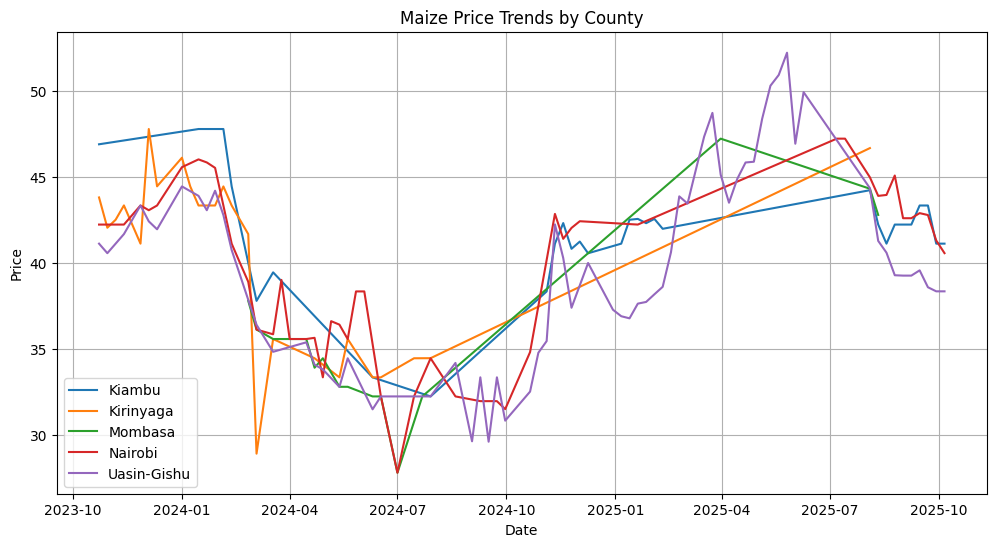

In [33]:
plt.figure(figsize=(12,6))

for county in TARGET_COUNTIES:
    temp = final_df[final_df['County'] == county]
    plt.plot(temp['Date'], temp['price'], label=county)

plt.title("Maize Price Trends by County")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

**Target Distribution**

The target variable shows an approximately normal distribution, indicating that most price changes are centered around a stable mean with fewer extreme fluctuations. This is a positive sign for modeling, as it suggests the data is well-behaved and does not contain excessive skewness or outliers. It also implies that the model will learn general market behavior more effectively, improving prediction stability and reliability.

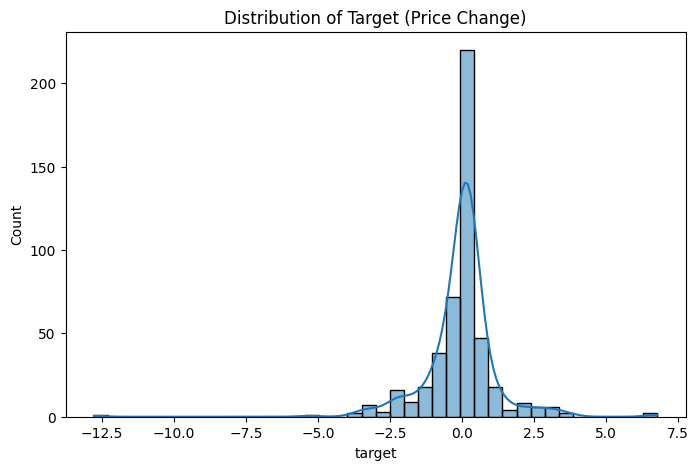

In [35]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(final_df['target'], bins=40, kde=True)
plt.title("Distribution of Target (Price Change)")
plt.show()

**Feature Correlation**

Feature correlation visualization helps us understand how different variables relate to each other and to the target. It is important for detecting strong predictors, removing redundant features, and ensuring the model learns meaningful relationships without noise.

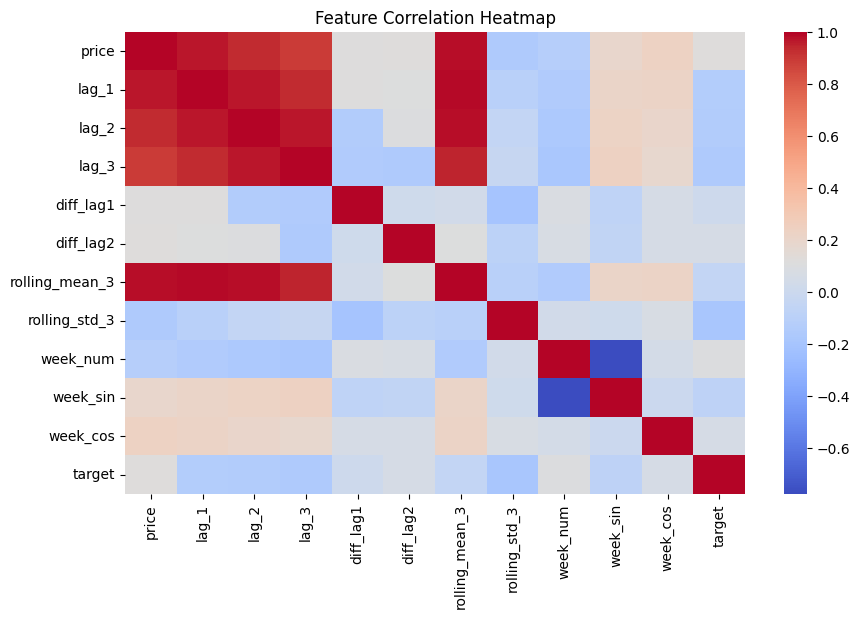

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(final_df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

**Lag Relation**

Lag feature visualization shows how past prices influence current or future prices. It confirms whether historical values (e.g., previous week prices) have predictive power, which is the foundation of time-series forecasting models.

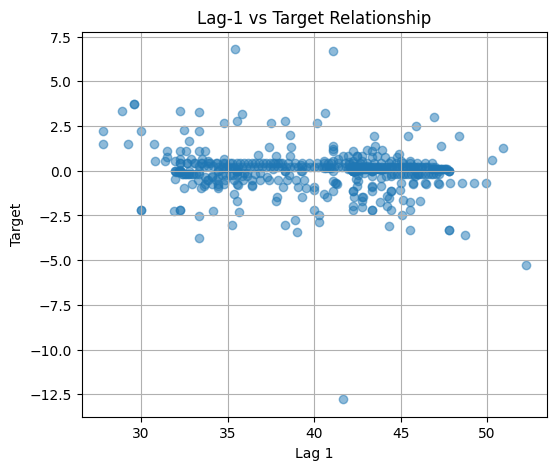

In [37]:
plt.figure(figsize=(6,5))
plt.scatter(final_df['lag_1'], final_df['target'], alpha=0.5)
plt.title("Lag-1 vs Target Relationship")
plt.xlabel("Lag 1")
plt.ylabel("Target")
plt.grid(True)
plt.show()

**Seasonality Check**

Seasonality visualization shows repeating patterns in maize prices over weeks or months. It helps identify predictable cycles such as harvest and shortage periods, which improve the model's ability to learn time-based patterns and make more accurate forecasts.

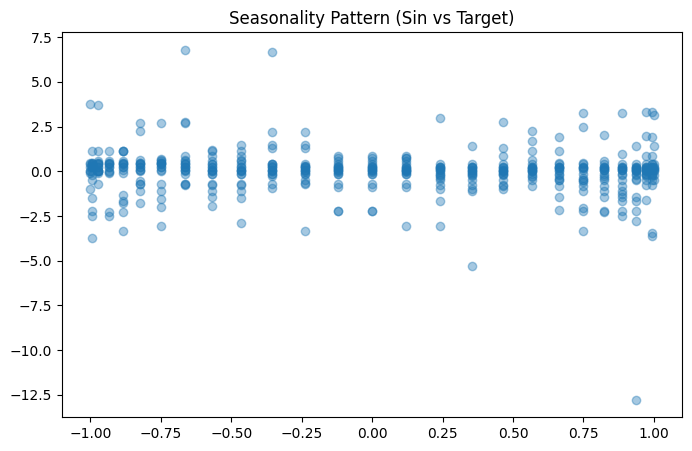

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(final_df['week_sin'], final_df['target'], alpha=0.4)
plt.title("Seasonality Pattern (Sin vs Target)")
plt.show()